# Reviewer-response analysis — LLM-guided counterfactual recourse

This notebook contains the **additional experiments** run to answer the
Scandinavian Actuarial Journal referee report. Each section maps to a specific
concern and is self-contained: it reloads the saved models, validation splits,
and guardrail modules and recomputes its result from scratch.

| Section | Referee concern | What it shows |
|---|---|---|
| 1 | #1 optimiser-dependence | The C1-vs-C2 collapse reproduces under a **non-DiCE** optimiser |
| 2 | #1 mechanism | *Why* post-hoc filtering empties out: directional/coupled violations |
| 3 | #1 box tightness | Widening the admissible box does **not** rescue post-hoc filtering |
| 4 | #3 + #4 | LLM tiers vs the rule: rigorous stats (Holm), and *value* not just difference |

**Environment.** Same artefacts as the paper (`../data/`): `df_final.pkl`,
`agent_config.pkl`, gender-specific `model_*.pkl`, `val_*.pkl`. Cohort =
155 model-confirmed Class-3 patients (89 male, 66 female).


In [1]:
import os, time, warnings, joblib
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import guardrail_core as gc
import experiment_core as ec

DATA, TAB, FIG = "../data", "../results/tables", "../results/figures"
df_final = joblib.load(os.path.join(DATA, "df_final.pkl"))
ac = joblib.load(os.path.join(DATA, "agent_config.pkl"))
X, T, VARY = ac["X_features"], ac["target_col"], ac["vary_features"]

def cohort(gender_code, model_file, val_file):
    model = joblib.load(os.path.join(DATA, model_file))
    val = joblib.load(os.path.join(DATA, val_file))
    idx = val["X_val"][(val["y_val"] == 3) &
                       (model.predict(val["X_val"]) == 3)].index.tolist()
    df_stable = df_final[df_final["Sex"] == gender_code].copy().astype(float)
    return model, val, df_stable, idx

for gc_code, name, mf, vf in [(1.0,"Male","model_male.pkl","val_male.pkl"),
                              (2.0,"Female","model_female.pkl","val_female.pkl")]:
    _,_,_,idx = cohort(gc_code, mf, vf)
    print(f"{name}: {len(idx)} model-confirmed Class 3 patients")

Male: 89 model-confirmed Class 3 patients


Female: 66 model-confirmed Class 3 patients


## 1. Optimiser-independence (referee concern #1)

The paper's headline result uses DiCE (genetic search). A referee could object
that the post-hoc collapse is a quirk of that optimiser. Here we reproduce the
**C1 (post-hoc) vs C2 (pre-injection)** contrast with a *completely independent*
random-search counterfactual generator — no genetic algorithm, no shared code
with DiCE.

- **RS-C1**: sample perturbations from a broad unconstrained box, keep those the
  model maps to Class 0, then filter survivors against the admissible box `G(x)`.
- **RS-C2**: sample perturbations from *inside* `G(x)` directly (stepwise
  fallback 0→1→2).


In [2]:
SEED = 20260908
N_SAMPLES = 200

def sample_box(cur, box, rng, n):
    cols = {}
    for f in X:
        if f in VARY and f in box:
            lo, hi = box[f]
            cols[f] = rng.uniform(lo, hi, n) if hi > lo else np.full(n, cur[f])
        else:
            cols[f] = np.full(n, cur[f])
    return pd.DataFrame(cols)[X]

def unconstrained_box(cur):
    return {f: [min(cur[f]*0.7, cur[f]*1.3), max(cur[f]*0.7, cur[f]*1.3)] for f in VARY}

def in_adm(row, box):
    return all(box[f][0]-1e-6 <= float(row[f]) <= box[f][1]+1e-6 for f in X if f in box)

def run_rs(gc_code, name, mf, vf):
    model, val, _, idx = cohort(gc_code, mf, vf)
    rows = []
    for pid in idx:
        rng = np.random.default_rng(SEED + hash(str(pid)) % 10000)
        q = val["X_val"].loc[[pid]][X]; cur = {f: float(q.iloc[0][f]) for f in X}
        g_adm = gc.build_rule_guardrails(cur, X, "aggressive")
        cand = sample_box(cur, unconstrained_box(cur), rng, N_SAMPLES)
        c0 = cand[model.predict(cand[X]) == 0]
        c1 = len(c0) > 0 and any(in_adm(r, g_adm) for _, r in c0.iterrows())
        c2 = False
        for tgt in [0,1,2]:
            c = sample_box(cur, g_adm, rng, N_SAMPLES)
            if (model.predict(c[X]) == tgt).sum() > 0: c2 = True; break
        rows.append({"pid":pid,"gender":name,"rs_c0":len(c0)>0,"rs_c1":c1,"rs_c2":c2})
    return pd.DataFrame(rows)

opt = pd.concat([run_rs(1.0,"Male","model_male.pkl","val_male.pkl"),
                 run_rs(2.0,"Female","model_female.pkl","val_female.pkl")], ignore_index=True)

summary = []
for g in ["Male","Female"]:
    s = opt[opt.gender==g]
    summary.append([g, f"{s.rs_c0.mean()*100:.1f}%", f"{s.rs_c1.mean()*100:.1f}%", f"{s.rs_c2.mean()*100:.1f}%"])
summary.append(["Pooled", f"{opt.rs_c0.mean()*100:.1f}%", f"{opt.rs_c1.mean()*100:.1f}%", f"{opt.rs_c2.mean()*100:.1f}%"])
pd.DataFrame(summary, columns=["gender","RS-C0 unconstrained","RS-C1 post-hoc","RS-C2 pre-injection"])

,gender,RS-C0 unconstrained,RS-C1 post-hoc,RS-C2 pre-injection
0,Male,98.9%,5.6%,96.6%
1,Female,100.0%,4.5%,100.0%
2,Pooled,99.4%,5.2%,98.1%


**Result.** The random-search optimiser reproduces the paper's pattern:
post-hoc filtering collapses (pooled ≈ 5%) while pre-injection preserves
feasibility (pooled ≈ 98%). The injection-point effect is a property of *where*
constraints enter, not of the genetic optimiser.

## 2. Why post-hoc filtering collapses (referee concern #1, mechanism)

For every unconstrained DiCE candidate across the cohort, we record which
admissibility constraint *types* it violates — **independently**. This shows the
collapse is driven by direction/coupling geometry, not a tunable box width.

In [3]:
ANTHRO = ["BMI","WaistCirc","Weight"]
NOINC  = ["Energy_kcal","Sodium_mg","Carb_g","Sugar_g"]
FLOORS = {"Energy_kcal":500.,"Sodium_mg":800.,"Protein_g":30.,"Potassium_mg":500.,"Carb_g":30.,"Fiber_g":5.}

def viol_types(row, cur):
    g = gc.build_rule_guardrails(cur, X, "aggressive")
    v_range = any(not (g[f][0]-1e-6 <= float(row[f]) <= g[f][1]+1e-6) for f in X)
    v_noinc = any(float(row[f]) > cur[f]+1e-6 for f in ANTHRO+NOINC)
    ratios = [(cur[f]-float(row[f]))/cur[f] if cur[f]>1e-9 else 0. for f in ANTHRO]
    v_couple = (min(ratios) < -1e-6) or (max(ratios)-min(ratios) > 0.15)
    v_floor = any(float(row[f]) < fl-1e-6 for f,fl in FLOORS.items())
    return v_range, v_noinc, v_couple, v_floor

def run_breakdown(gc_code, name, mf, vf):
    model, val, df_stable, idx = cohort(gc_code, mf, vf)
    exp = ec.make_dice(model, df_stable, X, T); out = []
    for pid in idx:
        q = val["X_val"].loc[[pid]][X]; cur = {f: float(q.iloc[0][f]) for f in X}
        cand = None
        for _ in range(5):
            try:
                cf = exp.generate_counterfactuals(q, total_CFs=4, desired_class=0,
                    features_to_vary=VARY, proximity_weight=0.2, sparsity_weight=0.1)
                d = cf.cf_examples_list[0].final_cfs_df
                if d is not None and len(d) > 0: cand = d.copy(); break
            except Exception: continue
        if cand is None: continue
        for _, r in cand.iterrows():
            vr,vn,vc,vf_ = viol_types(r, cur)
            out.append({"v_range":vr,"v_noinc":vn,"v_couple":vc,"v_floor":vf_,
                        "admissible":not(vr or vn or vc or vf_)})
    return pd.DataFrame(out)

vb = pd.concat([run_breakdown(1.0,"Male","model_male.pkl","val_male.pkl"),
                run_breakdown(2.0,"Female","model_female.pkl","val_female.pkl")], ignore_index=True)
pd.DataFrame([
 ["outside magnitude box", f"{vb.v_range.mean()*100:.1f}%"],
 ["increased a reduce-only feature", f"{vb.v_noinc.mean()*100:.1f}%"],
 ["broke anthropometric coupling", f"{vb.v_couple.mean()*100:.1f}%"],
 ["crossed a Layer-1 floor", f"{vb.v_floor.mean()*100:.1f}%"],
 ["fully admissible", f"{vb.admissible.mean()*100:.1f}%"],
], columns=["constraint type", f"candidates violating (n={len(vb)})"])

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.37it/s]

100%|██████████| 1/1 [00:00<00:00,  3.35it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.45it/s]

...

100%|██████████| 1/1 [00:00<00:00,  2.25it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.30it/s]

100%|██████████| 1/1 [00:00<00:00,  2.29it/s]

,constraint type,candidates violating (n=610)
0,outside magnitude box,100.0%
1,increased a reduce-only feature,90.8%
2,broke anthropometric coupling,48.7%
3,crossed a Layer-1 floor,35.9%
4,fully admissible,0.0%


## 3. Box-tightness sweep (referee concern #1, robustness)

Does post-hoc filtering fail only because the admissible box is *tight*? We reuse
each patient's single unconstrained candidate set and re-filter it against boxes
scaled by `alpha` about the current value (`alpha=1` = the paper's rule box;
`alpha>1` looser). If widening rescued C1, feasibility would climb with `alpha`.

In [4]:
ALPHAS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]

def scaled_box(cur, alpha):
    g = gc.build_rule_guardrails(cur, X, "aggressive"); out = {}
    for f in X:
        lo, hi = g[f]; c = cur[f]
        out[f] = [c + (lo-c)*alpha, c + (hi-c)*alpha]
    return gc.apply_layer1_safety(out, cur)

def run_tight(gc_code, name, mf, vf):
    model, val, df_stable, idx = cohort(gc_code, mf, vf)
    exp = ec.make_dice(model, df_stable, X, T); rows = []
    for pid in idx:
        q = val["X_val"].loc[[pid]][X]; cur = {f: float(q.iloc[0][f]) for f in X}
        cand = None
        for _ in range(5):
            try:
                cf = exp.generate_counterfactuals(q, total_CFs=4, desired_class=0,
                    features_to_vary=VARY, proximity_weight=0.2, sparsity_weight=0.1)
                d = cf.cf_examples_list[0].final_cfs_df
                if d is not None and len(d) > 0: cand = d.copy(); break
            except Exception: continue
        rec = {}
        for a in ALPHAS:
            if cand is None: rec[a] = False
            else:
                box = scaled_box(cur, a)
                rec[a] = any(all(box[f][0]-1e-6 <= float(r[f]) <= box[f][1]+1e-6 for f in X)
                             for _, r in cand.iterrows())
        rows.append(rec)
    return pd.DataFrame(rows)

tt = pd.concat([run_tight(1.0,"Male","model_male.pkl","val_male.pkl"),
                run_tight(2.0,"Female","model_female.pkl","val_female.pkl")], ignore_index=True)
pd.DataFrame([[a, f"{tt[a].mean()*100:.1f}%"] for a in ALPHAS],
             columns=["alpha (x rule half-width)","post-hoc feasibility"])

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.79it/s]

100%|██████████| 1/1 [00:00<00:00,  3.78it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.66it/s]

...

100%|██████████| 1/1 [00:00<00:00,  2.24it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.41it/s]

100%|██████████| 1/1 [00:00<00:00,  2.40it/s]

,alpha (x rule half-width),post-hoc feasibility
0,0.25,0.0%
1,0.50,0.0%
2,0.75,0.0%
3,1.00,0.0%
4,1.50,0.0%
5,2.00,0.0%
6,3.00,0.0%
7,5.00,0.6%


**Result.** Even at `alpha=5` (a box five times the rule half-width),
post-hoc feasibility stays at 0%. The obstacle is the directional/coupling
geometry (Section 2), which symmetric widening cannot fix.

## 4. LLM tiers vs the rule (referee concerns #3 and #4)

Uses the existing full-cohort (n=155) per-patient LLM records
(`llm_tier_divergence.csv`) — no re-querying of the models.

**#4 rigour:** Friedman across tiers; pairwise Wilcoxon with **Holm** correction
and matched-pairs rank-biserial effect sizes; the floor-necessity argument rests
on breach *point estimates*, not a non-significant test.

**#3 value:** on the same 155 patients, does delegation *buy* anything over the
rule (feasibility, sparsity), or merely differ from it?

In [5]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

llm = pd.read_csv(os.path.join(TAB, "llm_tier_divergence.csv"))
m = pd.read_csv(os.path.join(TAB, "_cohort_male.csv"))
f = pd.read_csv(os.path.join(TAB, "_cohort_female.csv"))
rule = pd.concat([m,f], ignore_index=True)
rule = rule[(rule.cond=="C2_pre_rule") & (rule.deleg=="aggressive")]
TIERS = ["weak","mid","strong"]

def holm(pv):
    idx = np.argsort(pv); adj = np.empty(len(pv)); prev = 0.
    for rank, i in enumerate(idx):
        prev = max(prev, min((len(pv)-rank)*pv[i], 1.)); adj[i] = prev
    return adj

def rank_biserial(x, y):
    d = np.asarray(x)-np.asarray(y); d = d[d!=0]
    if len(d)==0: return 0.
    r = pd.Series(np.abs(d)).rank().values
    Rp, Rn = r[d>0].sum(), r[d<0].sum(); T = Rp+Rn
    return float((Rp-Rn)/T) if T>0 else 0.

P = llm.pivot_table(index=["pid","gender"], columns="tier", values="mean_iou").dropna()
print(f"AXIS 1 — Interval IoU vs rule (n={len(P)})")
print("  tier means:", {t: round(P[t].mean(),4) for t in TIERS})
stat,p = friedmanchisquare(*[P[t] for t in TIERS])
print(f"  Friedman chi2={stat:.2f}, p={p:.2e}")
pairs = list(combinations(TIERS,2)); praw=[wilcoxon(P[a],P[b])[1] for a,b in pairs]
for (a,b),pr,pa in zip(pairs, praw, holm(praw)):
    print(f"  {a} vs {b}: Holm p={pa:.2e}, rank-biserial={rank_biserial(P[a],P[b]):+.3f}")

AXIS 1 — Interval IoU vs rule (n=155)
  tier means: {'weak': np.float64(0.4293), 'mid': np.float64(0.3757), 'strong': np.float64(0.4017)}
  Friedman chi2=21.25, p=2.43e-05
  weak vs mid: Holm p=9.75e-08, rank-biserial=+0.512
  weak vs strong: Holm p=6.20e-03, rank-biserial=+0.253
  mid vs strong: Holm p=4.67e-03, rank-biserial=-0.282


In [6]:
Pb = llm.pivot_table(index=["pid","gender"], columns="tier", values="raw_safety_breaches").dropna()
print("AXIS 3 — Raw safety-floor breaches (floor-necessity by point estimate)")
for t in TIERS:
    print(f"  {t:6s}: mean={Pb[t].mean():.3f}, {(Pb[t]>0).mean()*100:.1f}% of patients have >=1 breach")
print("  => every tier breaches for ~1/4 of patients; the code floor is required regardless.")

AXIS 3 — Raw safety-floor breaches (floor-necessity by point estimate)
  weak  : mean=0.516, 26.5% of patients have >=1 breach
  mid   : mean=0.297, 21.3% of patients have >=1 breach
  strong: mean=0.374, 28.4% of patients have >=1 breach
  => every tier breaches for ~1/4 of patients; the code floor is required regardless.


In [7]:
print("AXIS 2 — Does delegation buy anything vs the rule? (paired, same 155)")
ridx = rule.set_index(["pid","gender"])
print(f"\nFeasibility  rule={rule.feasible.mean()*100:.1f}%")
for t in TIERS:
    Lt = llm[llm.tier==t].set_index(["pid","gender"])
    common = Lt.index.intersection(ridx.index)
    a = Lt.loc[common,"feasible"].astype(float).values
    b = ridx.loc[common,"feasible"].astype(float).values
    d = a-b; pw = wilcoxon(d)[1] if np.any(d!=0) else 1.0
    print(f"  {t:6s}: LLM={a.mean()*100:.1f}%  (delta={d.mean()*100:+.1f}pp, p={pw:.2e})")
print(f"\nSparsity (vars changed; lower=sparser)  rule={rule.loc[rule.feasible.astype(bool),'n_changed_vars'].mean():.2f}")
for t in TIERS:
    Lt = llm[llm.tier==t].set_index(["pid","gender"])
    common = Lt.index.intersection(ridx.index)
    sub = pd.DataFrame({"lf":Lt.loc[common,"feasible"].astype(bool).values,
                        "ln":Lt.loc[common,"n_changed_vars"].values,
                        "rf":ridx.loc[common,"feasible"].astype(bool).values,
                        "rn":ridx.loc[common,"n_changed_vars"].values})
    j = sub[sub.lf & sub.rf].dropna()
    d = j.ln.values-j.rn.values; pw = wilcoxon(d)[1] if np.any(d!=0) else 1.0
    print(f"  {t:6s}: LLM={j.ln.mean():.2f} vs rule={j.rn.mean():.2f}  (delta={d.mean():+.2f}, p={pw:.2e}, n={len(j)})")

AXIS 2 — Does delegation buy anything vs the rule? (paired, same 155)

Feasibility  rule=98.7%
  weak  : LLM=96.1%  (delta=-2.6pp, p=4.55e-02)
  mid   : LLM=94.8%  (delta=-3.9pp, p=5.78e-02)
  strong: LLM=97.4%  (delta=-1.3pp, p=3.17e-01)

Sparsity (vars changed; lower=sparser)  rule=10.61
  weak  : LLM=13.92 vs rule=10.48  (delta=+3.44, p=2.19e-14, n=149)
  mid   : LLM=11.65 vs rule=10.40  (delta=+1.25, p=5.37e-05, n=145)
  strong: LLM=14.98 vs rule=10.52  (delta=+4.45, p=3.07e-18, n=150)


**Result.** The LLM ranges genuinely differ from the rule (IoU ≈ 0.4,
Holm-corrected p ≪ 0.001), but the difference does **not** improve recourse:
feasibility is no higher than the rule and sparsity is worse at every tier.
Combined with the breach analysis (every tier violates floors for ~1/4 of
patients), this is the empirical case for the three-layer design — safety pinned
in code, discretion delegated but held to a rule-competitive baseline.

## 5. Figures used in the manuscript

The two grayscale figures below (also saved to `../results/figures/`) summarise
Sections 1–4.

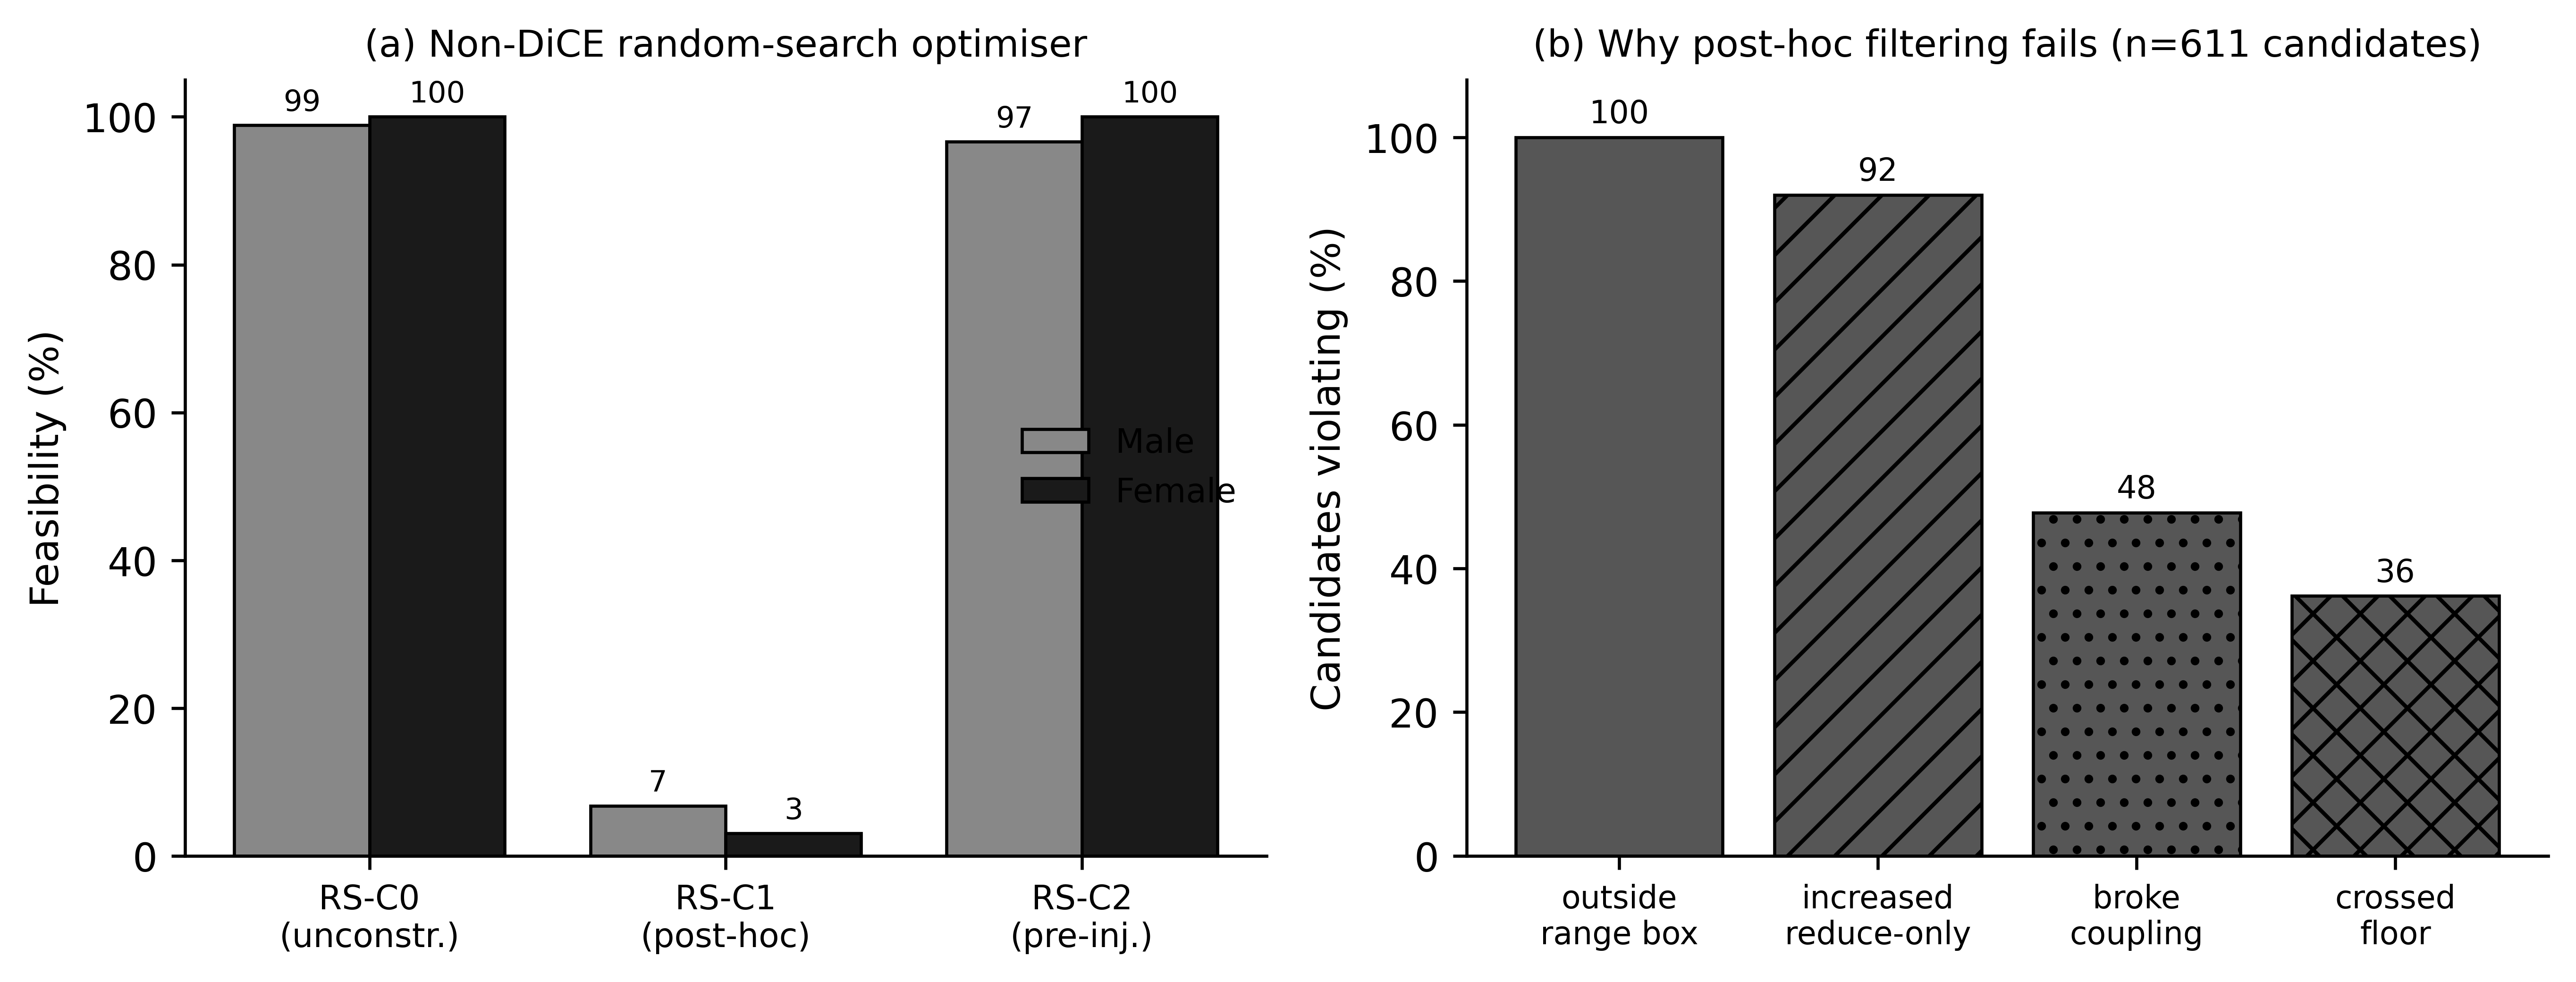

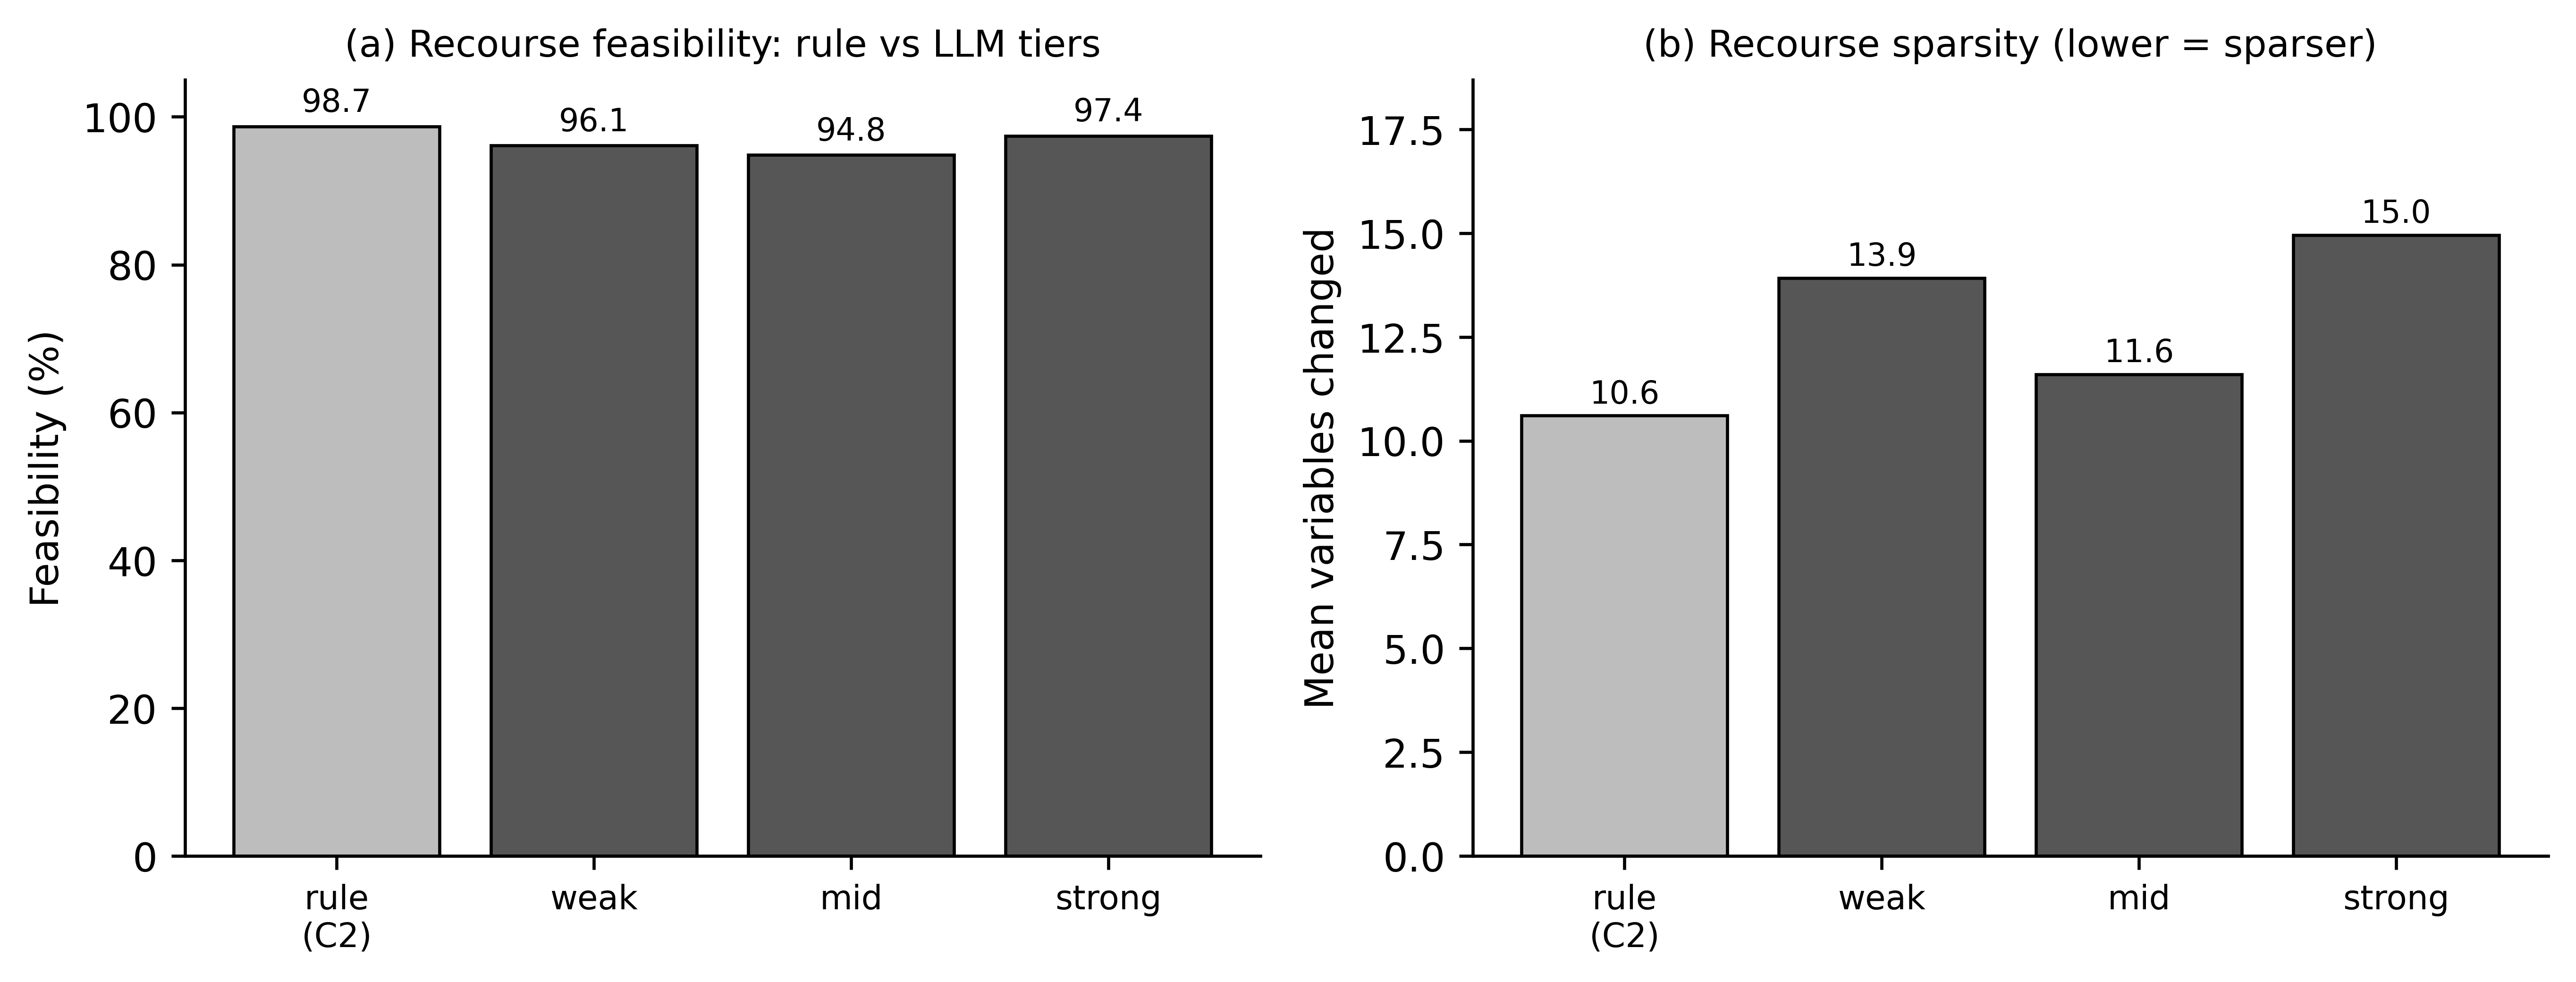

In [8]:
from IPython.display import Image, display
display(Image(filename=os.path.join(FIG, "fig_optimizer_independence.png")))
display(Image(filename=os.path.join(FIG, "fig_llm_vs_rule_value.png")))